# Insurance Charges - Exploratory Data Analysis
**Dataset:** Medical Cost Personal Dataset | **Source:** Kaggle  
**Goal:** Understand the structure, distributions, and relationships in the data before any cleaning or modelling.

| Column | Type | Description |
|---|---|---|
| age | Numeric | Age of the primary beneficiary |
| sex | Categorical | Gender of the policyholder |
| bmi | Numeric | Body Mass Index |
| children | Numeric | Number of dependents covered |
| smoker | Categorical | Whether the beneficiary smokes |
| region | Categorical | Residential area in the US |
| charges | Numeric | Individual medical costs billed (our target variable) |

## 1. Imports & Data Loading

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

In [17]:
data = pd.read_csv('../data/insurance.csv')
data.head() # reads first 5 rows

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Dataset Overview
Here we will understand the shape, information, data types and description of our data set.

In [18]:
print("Shape:", data.shape)
print(data.dtypes)
#it has 1338 rows and 7 columns

Shape: (1338, 7)
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [19]:
data.describe() #gets count , mean , median ,etc of the numeric columns

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [20]:
# check for the total count of missing values
data.isnull().sum()

#zero null values so the data is already cleaned

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 3. Distributions
Histogram and KDE for each numeric column to understand their shape and distribution.

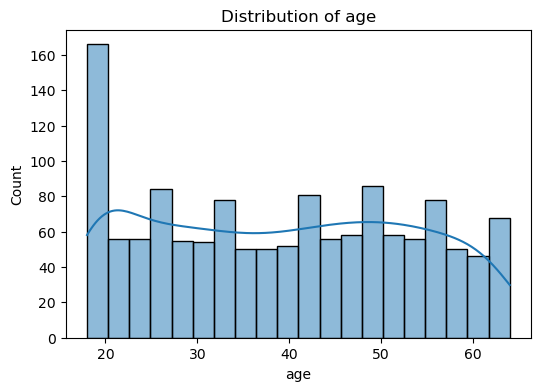

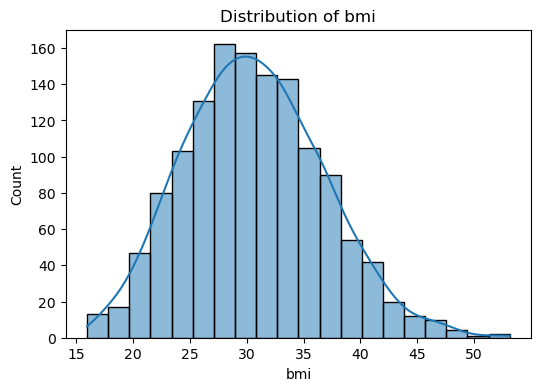

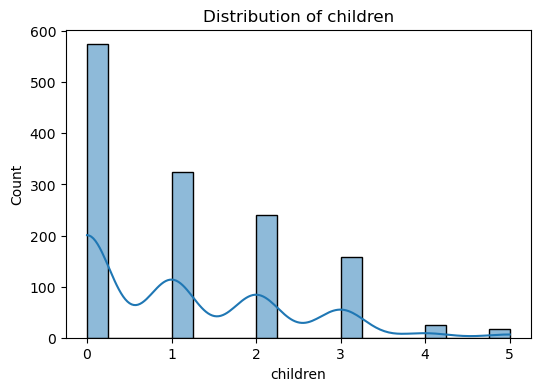

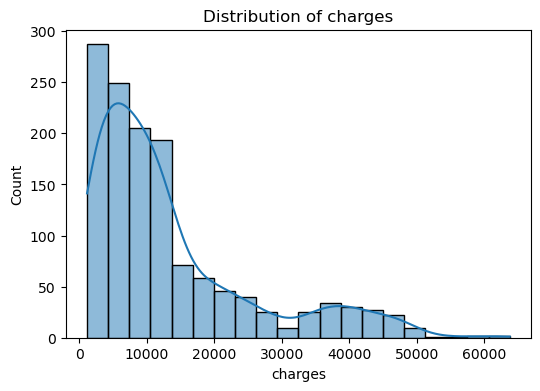

In [21]:
numeric_columns = ['age', 'bmi', 'children', 'charges']

for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    

Text(0.5, 1.0, 'Count of Children')

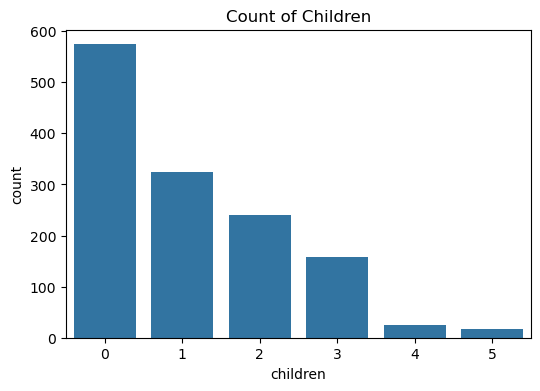

In [22]:
# children is discrete (0-5), countplot is clearer than histogram
plt.figure(figsize=(6, 4))
sns.countplot(x=data['children'])
plt.title('Count of Children')

## 4. Categorical Feature Distributions

Text(0.5, 1.0, 'Smoker Distribution')

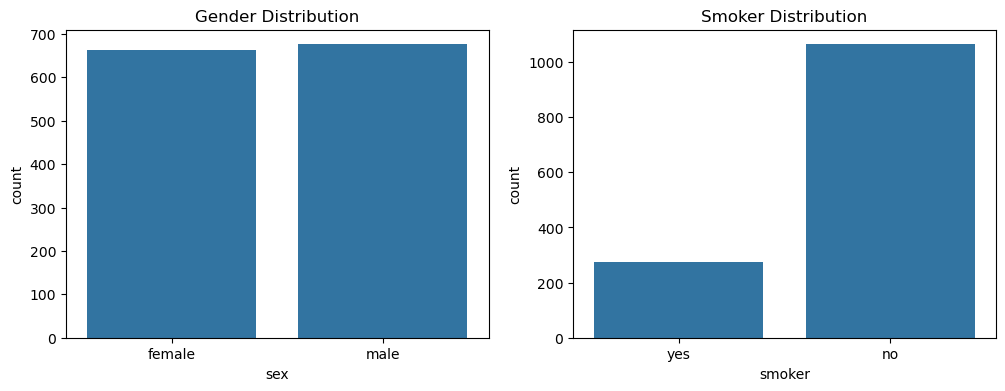

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=data['sex'], ax=axes[0])
axes[0].set_title('Gender Distribution')

sns.countplot(x=data['smoker'], ax=axes[1])
axes[1].set_title('Smoker Distribution')


## 5. Boxplots

A **boxplot** summarizes distribution through quartiles and is the best tool for spotting outliers.

- **Median line:** exact middle value  
- **Box (IQR):** middle 50% of data (Q1 to Q3)  
- **Whiskers:** extend to 1.5 × IQR from the box edges  
- **Dots beyond whiskers:** outliers are values that fall outside the normal range

### 5.1 Smoker vs Charges

Text(0.5, 1.0, 'Smoker vs Insurance Charges')

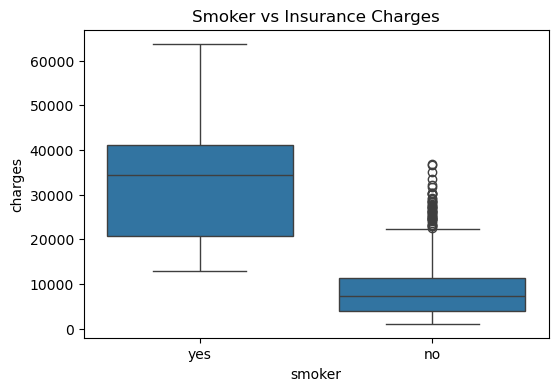

In [24]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['smoker'], y=data['charges'])
plt.title('Smoker vs Insurance Charges')

**Key Insight:**  
The cheapest bill for a smoker (~$13,000) is higher than what 75% of non-smokers pay.  
Non-smoker charges are low and predictable (narrow box). Smoker charges are high and spread out (wide box).  
Dots above the non-smoker box represent people paying above-normal charges due to age, high BMI, or other factors, smoking is not the only driver.

### 5.2 Numeric Columns Outlier Check

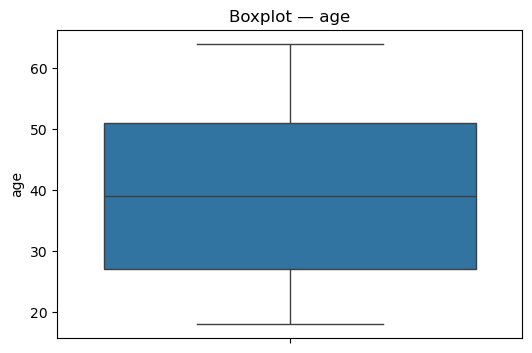

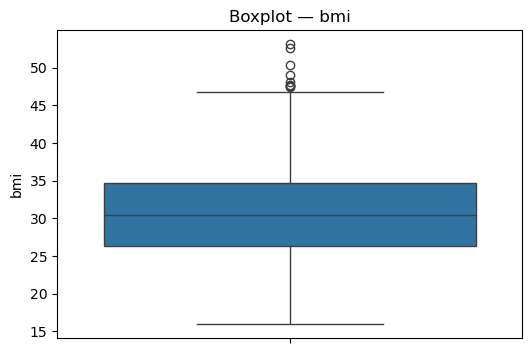

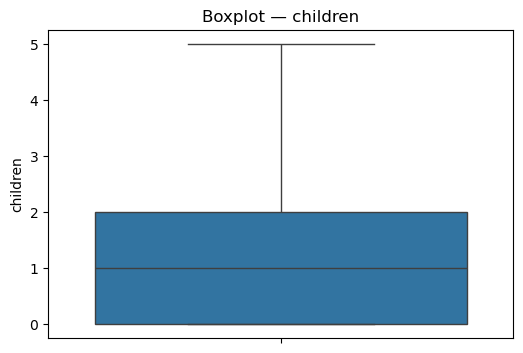

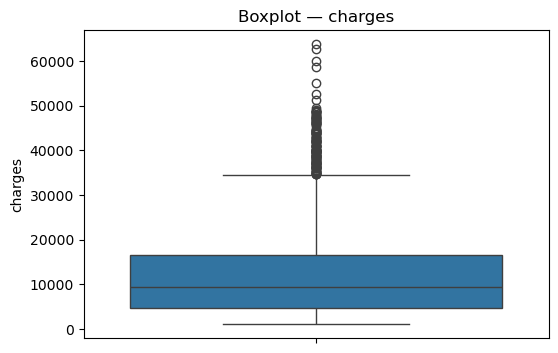

In [25]:
for col in ['age', 'bmi', 'children', 'charges']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data[col])
    plt.title(f'Boxplot — {col}')
    

## 6. Correlation Heatmap

A heatmap visualizes the Pearson correlation matrix by how strongly each numeric column moves together with others.

- Value close to **+1**: strong positive relationship  
- Value close to **-1**: strong negative relationship  
- Value close to **0**: no linear relationship  

**Why it matters:**  
1. Identify which features are driving `charges`  
2. Spot multicollinearity — two features saying the same thing (which confuses models)

Text(0.5, 1.0, 'Correlation Heatmap')

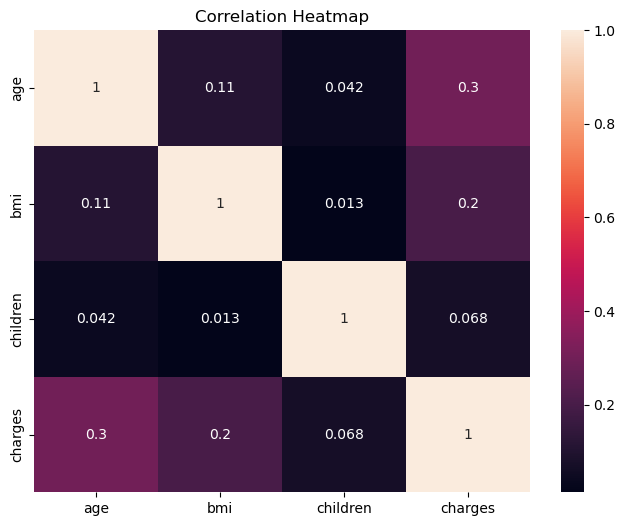

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')

**Insight:** `charges` and `age` have a moderate positive correlation. `children` has near-zero correlation with everything. No strong feature-to-feature correlations visible.

## 7. Statistical Feature Selection

### 7.1 Pearson Correlation (for numeric features)

Pearson correlation gives us both the strength (r) and a p-value to confirm the relationship is statistically real and not a coincidence of sample size.

- **r value:** direction and strength (-1 to +1)  
- **p-value < 0.05:** we are 95% confident the relationship is real

In [27]:
from scipy.stats import pearsonr

selected_features = ['age', 'bmi', 'children']

results = {}
for feature in selected_features:
    r, p = pearsonr(data[feature], data['charges'])
    results[feature] = {'r': round(r, 4), 'p_value': round(p, 6),
                        'significant': 'Yes' if p < 0.05 else 'No'}

pd.DataFrame(results).T.sort_values('r', ascending=False)

,r,p_value,significant
age,0.299,0.0,Yes
bmi,0.1983,0.0,Yes
children,0.068,0.012852,Yes


### 7.2 Chi-Square Test (for categorical features)

Chi-Square tests whether a categorical feature is statistically dependent on the target.  
Since `charges` is continuous, we bin it into 4 equal-frequency groups (quartiles) using `pd.qcut()` to make it compatible with the test.

**Null hypothesis:** the feature and charges are independent (unrelated)  
**p < 0.05:** reject null → feature is related to charges → keep it  
**p > 0.05:** accept null → feature is independent → candidate for dropping

In [28]:
from scipy.stats import chi2_contingency

# Bin charges into 4 equal-frequency groups for the test
charges_bin = pd.qcut(data['charges'], q=4, labels=False)

categorical_features = ['sex', 'smoker', 'region']
alpha = 0.05
chi2_results = {}

for col in categorical_features:
    table = pd.crosstab(data[col], charges_bin)
    chi2_stat, p_val, _, _ = chi2_contingency(table)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {'chi2_statistic': round(chi2_stat, 3),
                         'p_value': round(p_val, 6),
                         'decision': decision}

pd.DataFrame(chi2_results).T.sort_values('p_value')

,chi2_statistic,p_value,decision
smoker,854.02,0.0,Reject Null (Keep Feature)
region,20.692,0.01409,Reject Null (Keep Feature)
sex,9.532,0.022992,Reject Null (Keep Feature)


**Key Findings:**
- `smoker` is overwhelmingly the strongest predictor of charges
- `region` shows weak significance and may not contribute much to the model
- These findings guide feature selection in the preprocessing notebook